In [18]:
import numpy as np
import casadi as ca
import pandas as pd
import matplotlib.pyplot as plt
import pypesto 
import scipy
# 
from src.kinetics import *
import time
from src.param_estimation import *
import scipy.stats as stats
import seaborn as sns

In [21]:
# data_import
balanced_met_df   = pd.read_csv('Data/balanced_metabolites.csv', index_col=0)
imbalanced_met_df = pd.read_csv('Data/imbalanced_metabolites.csv', index_col=0)
prot_df           = pd.read_csv('Data/important_proteins.csv', index_col=0)
flux_df           = pd.read_csv('Data/important_fluxes.csv', index_col=0)
cell_needs_df     = pd.read_csv('Data/cellular_needs.csv', index_col=0)

# bounds
imbalanced_bounds = {}
total_min = 1e12
for met in imbalanced_met_df.index:
    
    imbalanced_bounds[met] = (imbalanced_met_df.loc[met].min()* 0.8, imbalanced_met_df.loc[met].max()    * 1.2)
    if imbalanced_bounds[met][0] < total_min:
        total_min = imbalanced_bounds[met][0]
imbalanced_bounds["C_pi"] = (total_min, 10.0)  # Pi is often in the mM range, but can vary widely; set a broad range.

# Tighter physiological bounds — replaces (1e-12, 100)

max_max_balanced = balanced_met_df.max().max() * 1.2
min_min_balanced = 0
balanced_bounds = {
    "C_g6p": (min_min_balanced, max_max_balanced), 
    "C_f6p": (min_min_balanced, max_max_balanced), 
    "C_fbp": (min_min_balanced, max_max_balanced), 
    "C_dhap": (min_min_balanced, max_max_balanced), 
    "C_g3p": (min_min_balanced, max_max_balanced), 
    "C_pgp": (min_min_balanced, max_max_balanced), 
    "C_3pg": (min_min_balanced, max_max_balanced), 
    "C_2pg": (min_min_balanced, max_max_balanced), 
    "C_pep": (min_min_balanced, max_max_balanced), 
}

model = EcoliCarbonKinetics(
         bounds_imbalanced_mets = imbalanced_bounds,
         bounds_balanced_mets = balanced_bounds,
        )


constants = {
    # v1: PTS (Sistema de fosfotransferasa)
    "kI_pyr_1": 0.5,  # Inhibición por piruvato
    "kA_pep_1": 0.3,  # Afinidad/Activación por PEP
    "v_max_1": 25.739,  # Flujo máximo típico en fase exponencial
    "Ka1_1": 1.0,  # Parámetros de la ecuación compleja del PTS
    "Ka2_1": 0.01,
    "Ka3_1": 1.0,
    "n_g6p_1": 4,  # Cooperatividad/Regulación por G6P
    "K_g6p_1": 0.5,
    # v2: PGI (Glucosa-6-fosfato isomerasa)
    "kI_pep_2": 0.12,  # Fuerte inhibición por PEP
    "Km_g6p_2": 0.48,
    "Km_f6p_2": 0.19,
    "kcat_f_2": 1475.0,  # Reacción muy rápida
    "kcat_r_2": 1000.0,
    # v3: PFK (Fosfofructoquinasa) - Enzima regulatoria clave
    "kI_f6p_3": 0.9,
    "kI_fbp_3": 2.0,
    "kI_gtp_3": 0.8,
    "kI_pep_3": 0.5,  # Inhibidor alostérico principal
    "kI_pi_3": 1.5,
    "kA_adp_3": 0.12,  # Activador alostérico
    "kA_gdp_3": 0.15,
    "Km_f6p_3": 0.16,
    "Km_atp_3": 0.12,
    "Km_fbp_3": 0.5,
    "Km_adp_3": 0.2,
    "kcat_f_3": 580.0,
    "kcat_r_3": 100.0,
    # v4: FBA (Fructosa-bisfosfato aldolasa)
    "kI_3pg_4": 2.0,
    "kI_dhap_4": 0.08,
    "kI_g3p_4": 0.1,
    "kA_pep_4": 1.5,
    "kcat_f_4": 95.0,
    "kcat_r_4": 150.0,
    "Km_fbp_4": 0.3,
    "Km_g3p_4": 0.4,
    "Km_dhap_4": 2.0,
    # v5: TPI (Triosafosfato isomerasa)
    "kcat_f_5": 4300.0,  # Cercana a la perfección catalítica
    "kcat_r_5": 2400.0,
    "Km_dhap_5": 0.61,
    "Km_g3p_5": 1.2,
    # v6: GAPDH (Gliceraldehído-3-fosfato deshidrogenasa)
    "kI_adp_6": 0.8,
    "kI_amp_6": 1.0,
    "kI_atp_6": 0.2,
    "kcat_f_6": 118.0,
    "kcat_r_6": 10.0,
    "Km_g3p_6": 0.21,
    "Km_pi_6": 0.29,
    "Km_nad_6": 0.09,
    "Km_pgp_6": 0.01,
    "Km_nadh_6": 0.06,
    # v7: PGK (Fosfoglicerato quinasa)
    "kA_3pg_7": 0.5,
    "kA_atp_7": 0.3,
    "kcat_f_7": 1150.0,
    "kcat_r_7": 40.0,
    "Km_pgp_7": 0.05,
    "Km_adp_7": 0.1,
    "Km_3pg_7": 0.53,
    "Km_atp_7": 0.3,
    # v8: GPM (Fosfoglicerato mutasa)
    "kI_pi_8": 10.0,  # Inhibición débil por Pi
    "kcat_f_8": 540.0,
    "kcat_r_8": 120.0,
    "Km_3pg_8": 0.2,
    "Km_2pg_8": 1.4,
    # v9: ENO (Enolasa)
    "kcat_f_9": 550.0,
    "kcat_r_9": 210.0,
    "Km_2pg_9": 0.1,
    "Km_pep_9": 0.5,
}


In [40]:
from joblib import Parallel, delayed

def perturb_param(param, constants, prot_df, cell_needs_df, model_kwargs, n_iter=10):
    model = EcoliCarbonKinetics(**model_kwargs)

    # Prime warm-start cache with nominal solutions
    for col in prot_df.columns:
        model.solve_steady_state(prot_df[col].to_dict(), cell_needs_df[col].to_dict(),
                                 constants, condition_key=col)

    param_values, solutions, fobjs = [], [], []
    for _ in range(n_iter):
        value  = np.random.normal(constants[param], constants[param] * 0.5)
        while value <= constants[param]*0.01:  # Ensure positive values for kinetic parameters
            value = np.random.normal(constants[param], constants[param] * 0.5)
        c = {**constants, param: value}
        # Allocate numeric arrays by length, not by list of keys (which are strings)
        num_vars = len(model.balanced_keys) + len(model.flux_keys)
        solution = np.zeros(num_vars)
        obj_total = 0.0
        for col in prot_df.columns:
            sol, obj_value = model.solve_steady_state(prot_df[col].to_dict(),
                                                     cell_needs_df[col].to_dict(),
                                                     c, condition_key=col)
            # Normalize sol to a numeric 1D array matching expected length
            if isinstance(sol, pd.Series):
                sol_array = sol.reindex(model.balanced_keys + model.flux_keys).values
            else:
                sol_array = np.asarray(sol).ravel()
            if sol_array.size != num_vars:
                raise ValueError(f"Unexpected solution length {sol_array.size} (expected {num_vars}) for condition {col}")
            solution = solution + sol_array  # Aggregate solutions across conditions
            obj_total += float(obj_value)  # Aggregate objective values
        param_values.append(value)
        average_solution = solution / len(prot_df.columns)  # Average solution across conditions
        average_obj = obj_total / len(prot_df.columns)  # Average objective value across conditions
        solutions.append(pd.Series(average_solution, index=model.balanced_keys + model.flux_keys))
        fobjs.append(average_obj)

    return param, {"param_values": param_values, "solutions": solutions, "fobjs": fobjs}

# Run all params in parallel (n_jobs=-1 uses all cores)
outputs = Parallel(n_jobs=-1, backend="loky")(
    delayed(perturb_param)(param, constants, prot_df, cell_needs_df,
                           model_kwargs={"bounds_imbalanced_mets": imbalanced_bounds, "bounds_balanced_mets": balanced_bounds}
    )
    for param in constants
)
values_dict = {param: res for param, res in outputs}

/Users/gabbi/Desktop/Repos/biosistemas/HybridKinetics-IIQ3733/src/kinetics.py:16: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  import scipy
/Users/gabbi/Desktop/Repos/biosistemas/HybridKinetics-IIQ3733/src/kinetics.py:16: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  import scipy
/Users/gabbi/Desktop/Repos/biosistemas/HybridKinetics-IIQ3733/src/kinetics.py:16: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  import scipy
/Users/gabbi/Desktop/Repos/biosistemas/HybridKinetics-IIQ3733/src/kinetics.py:16: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  import scipy
/Users/gabbi/Desktop/Repos/biosistemas/HybridKinetics-IIQ3733/src/kinetics.py:16: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version 

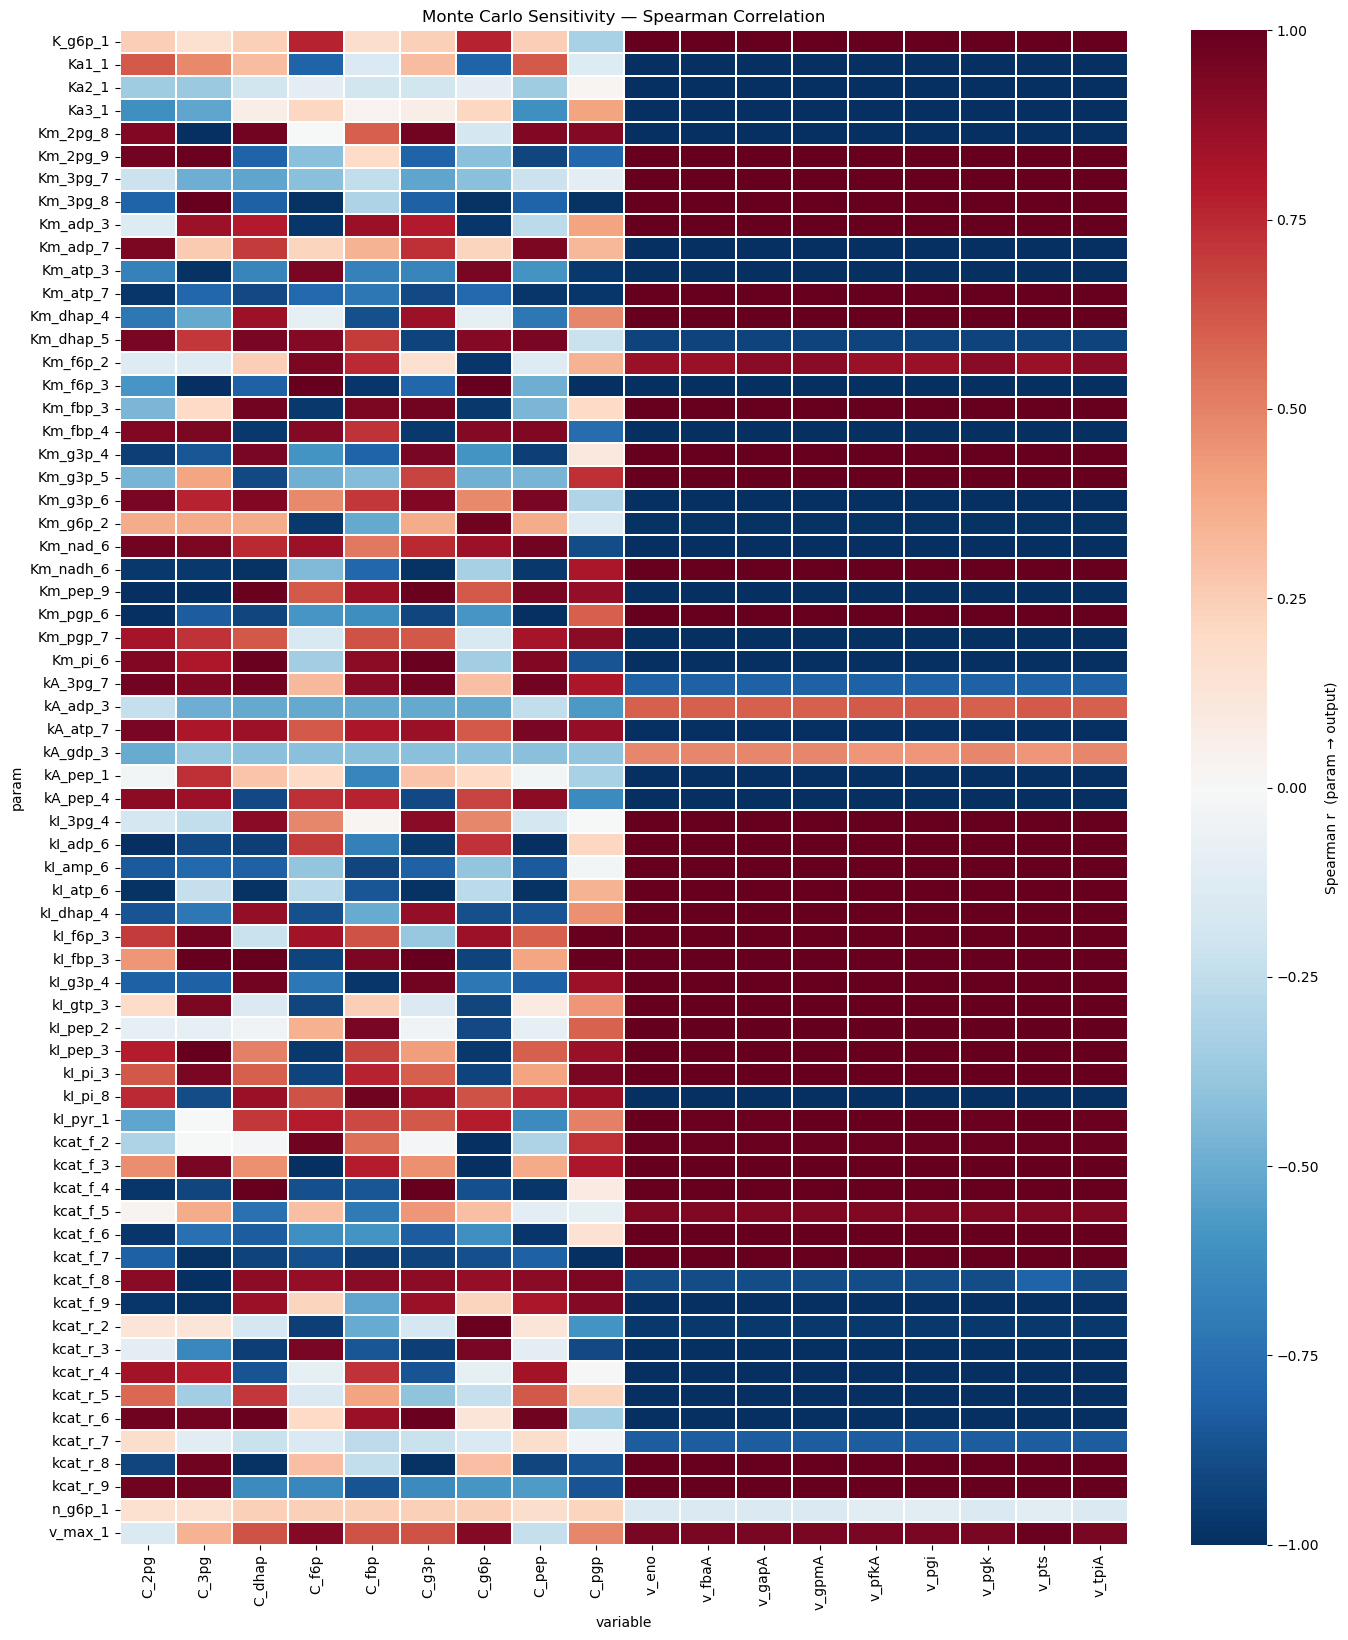

In [43]:
records = []
for param, data in values_dict.items():
    param_vals = np.array(data["param_values"])
    sol_df     = pd.DataFrame(data["solutions"])   # (n_iter × n_vars), one row per iteration

    order        = np.argsort(param_vals)           # sort by param value to expose trend
    param_sorted = param_vals[order]

    for var in sol_df.columns:
        out = sol_df[var].values[order]
        r, p = stats.spearmanr(param_sorted, out)
        records.append({"param": param, "variable": var, "r": r, "p": p})

sens_pivot = (pd.DataFrame(records)
              .groupby(["param", "variable"])["r"]
              .mean().unstack())

fig, ax = plt.subplots(figsize=(14, max(8, len(constants) * 0.25)))
sns.heatmap(sens_pivot, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax,
            cbar_kws={"label": "Spearman r  (param → output)"})
ax.set_title("Monte Carlo Sensitivity — Spearman Correlation")
plt.tight_layout()
# plt.savefig("sensitivity_heatmap.png", dpi=150)
plt.show()

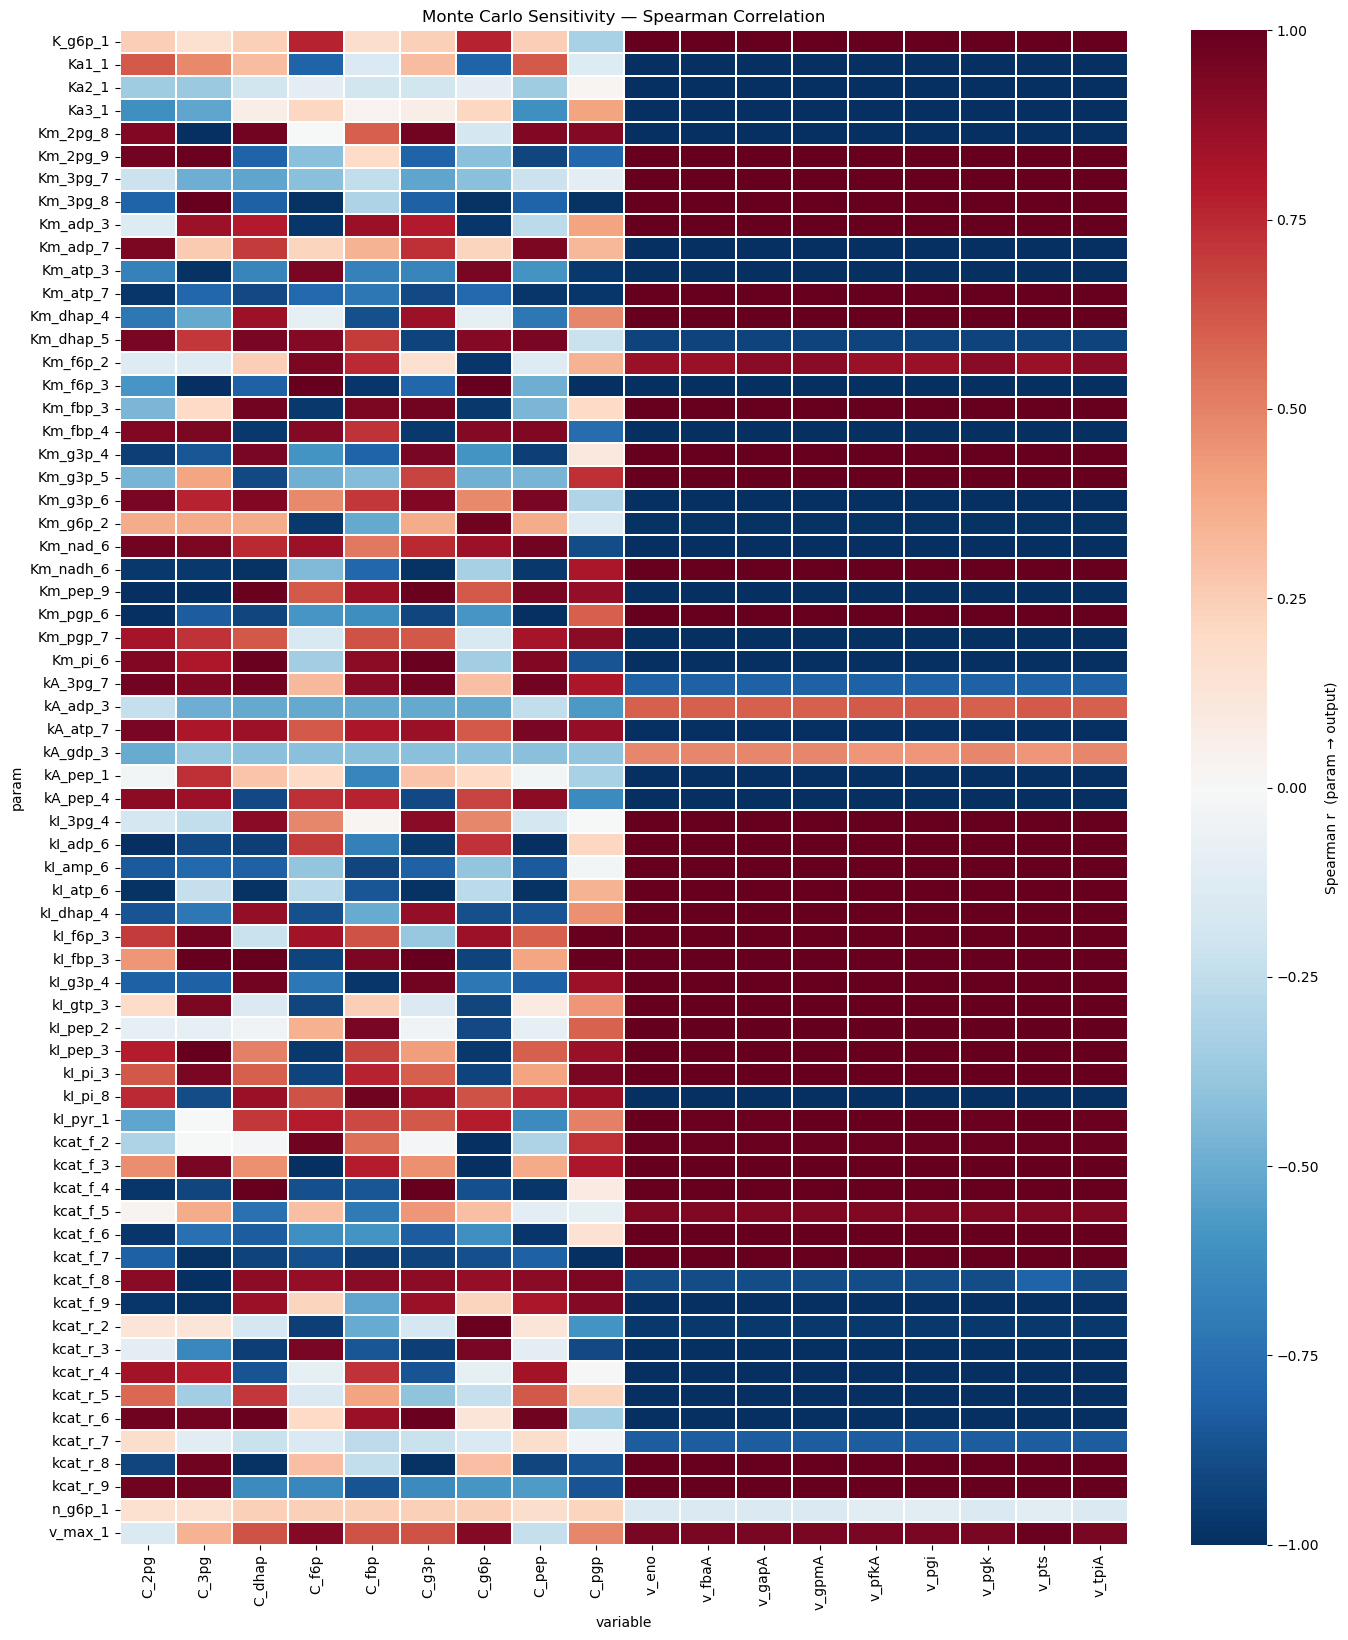

In [42]:
from matplotlib.backends.backend_pdf import PdfPages

records = []

with PdfPages("sensitivity_scatter.pdf") as pdf:
    for param, data in values_dict.items():
        param_vals = np.array(data["param_values"])
        sol_df     = pd.DataFrame(data["solutions"])
        order      = np.argsort(param_vals)
        param_sorted = param_vals[order]

        # ── correlations ──────────────────────────────────────────────────────
        param_records = []
        for var in sol_df.columns:
            out = sol_df[var].values[order]
            r, p = stats.spearmanr(param_sorted, out)
            records.append({"param": param, "variable": var, "r": r, "p": p})
            param_records.append((var, out, r))

        # ── scatter grid for this parameter ───────────────────────────────────
        n     = len(param_records)
        ncols = 5
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(ncols * 3, nrows * 2.8),
                                 constrained_layout=True)
        axes = np.array(axes).flatten()

        # sort subplots by |r| descending
        param_records.sort(key=lambda x: abs(x[2]), reverse=True)

        for ax, (var, out, r) in zip(axes, param_records):
            ax.scatter(param_sorted, out, s=25, alpha=0.75, color="steelblue")
            trend = np.poly1d(np.polyfit(param_sorted, out, 1))
            ax.plot(param_sorted, trend(param_sorted), "r--", lw=1.2)
            ax.set_title(f"{var}  (r={r:+.2f})", fontsize=8,
                         color="darkred" if abs(r) > 0.6 else "black")
            ax.set_xlabel(param, fontsize=7)
            ax.tick_params(labelsize=7)

        for ax in axes[n:]:          # hide unused subplots
            ax.set_visible(False)

        fig.suptitle(f"Sensitivity — {param}", fontsize=11, fontweight="bold")
        pdf.savefig(fig)
        plt.close(fig)

# ── heatmap (unchanged) ───────────────────────────────────────────────────────
sens_pivot = (pd.DataFrame(records)
              .groupby(["param", "variable"])["r"]
              .mean().unstack())

fig, ax = plt.subplots(figsize=(14, max(8, len(constants) * 0.25)))
sns.heatmap(sens_pivot, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax,
            cbar_kws={"label": "Spearman r  (param → output)"})
ax.set_title("Monte Carlo Sensitivity — Spearman Correlation")
plt.tight_layout()
plt.savefig("sensitivity_heatmap.png", dpi=150)
plt.show()